In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

%matplotlib inline

In [28]:
#titanic = pd.read_csv(r"titanic_train.csv", index_col='PassengerId')

In [3]:
titanic.shape

(891, 11)

In [4]:
# Looking for missing values
titanic.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [5]:
# We have missing values for 2 columns, however we will fill missing age with median age for each sex (0 (male), 1 (female)) because, the other one will not be used 

titanic["Age"] = titanic["Age"].fillna(titanic.groupby("Sex")["Age"].transform("median"))


In [6]:
# Sanity check, if the imputation was successful 

titanic.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age           0
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [7]:
# Will pick 3 columns to build a Logistic Regression model - no reason what so ever

feature_cols = ['Pclass', 'Parch', 'Age']
X = titanic[feature_cols]
y = titanic['Survived']

In [8]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

In [9]:
# Intantiate the model
logreg = LogisticRegression()

In [10]:
# Fit on train set
logreg.fit(X_train, y_train)

LogisticRegression()

In [11]:
# Check the performance on traing set - aka "score"
logreg_score = logreg.score(X_train, y_train)
print('accuracy = {:1.4f}'.format(logreg_score))

accuracy = 0.7201


In [12]:
y_pred_class = logreg.predict(X_test)

In [13]:
# Making predictions on the test set and checking the confusion matrix
# Survival	0 = No - Negative Class, 1 = Yes - Positive Class
y_pred_class = logreg.predict(X_test)
print(metrics.confusion_matrix(y_test, y_pred_class))

[[106  22]
 [ 52  43]]


In [14]:
# Printing below to navigate through the confusion matrix
print(np.asarray([['TN', 'FP'], ['FN', 'TP']]))

[['TN' 'FP']
 ['FN' 'TP']]


In [15]:
# True Negatives - 106 people who died, and this was predicticted correctly
# False Negatives - 52 people who survived and this was predicted incorrectly
# False Positives - 22 people who dies and this was predicted incorrectly
# True Positives - 43 People who survived and this was predicted correctly

## ROC UNDER THE HOOD

In [16]:
logreg.predict_proba(X_test) # probabilities for each observation per class - first column is for class 0, second column is for class 1. Hence why, we will then only subset the second column aka positive class with the addition of the following ---->>>> [:,1]. If we read the first line of the output, considering the first observation of our X_test data, probability of this observation being a class 0 is 0.4827, and probablitiy of the same observation to be a class 1 is 0.5172

array([[0.48275721, 0.51724279],
       [0.80609253, 0.19390747],
       [0.47044128, 0.52955872],
       [0.79425135, 0.20574865],
       [0.27028012, 0.72971988],
       [0.75556684, 0.24443316],
       [0.52482249, 0.47517751],
       [0.365755  , 0.634245  ],
       [0.30794882, 0.69205118],
       [0.79425135, 0.20574865],
       [0.78188273, 0.21811727],
       [0.78813302, 0.21186698],
       [0.53823019, 0.46176981],
       [0.58080132, 0.41919868],
       [0.79425135, 0.20574865],
       [0.30794882, 0.69205118],
       [0.55395436, 0.44604564],
       [0.77550056, 0.22449944],
       [0.843443  , 0.156557  ],
       [0.35073369, 0.64926631],
       [0.8228718 , 0.1771282 ],
       [0.78813302, 0.21186698],
       [0.27730448, 0.72269552],
       [0.47967707, 0.52032293],
       [0.70843386, 0.29156614],
       [0.79425135, 0.20574865],
       [0.17172568, 0.82827432],
       [0.69158437, 0.30841563],
       [0.55353268, 0.44646732],
       [0.26270726, 0.73729274],
       [0.

### 1. Find the predicted probabilities for the positive class - survived - Yes

In [17]:
probs = logreg.predict_proba(X_test)[:,1]
probs

array([0.51724279, 0.19390747, 0.52955872, 0.20574865, 0.72971988,
       0.24443316, 0.47517751, 0.634245  , 0.69205118, 0.20574865,
       0.21811727, 0.21186698, 0.46176981, 0.41919868, 0.20574865,
       0.69205118, 0.44604564, 0.22449944, 0.156557  , 0.64926631,
       0.1771282 , 0.21186698, 0.72269552, 0.52032293, 0.29156614,
       0.20574865, 0.82827432, 0.30841563, 0.44646732, 0.73729274,
       0.23765798, 0.68410249, 0.36958006, 0.21811727, 0.13578651,
       0.49213088, 0.62561142, 0.19390747, 0.71521231, 0.25133782,
       0.20574865, 0.30021387, 0.58862097, 0.5403097 , 0.77125658,
       0.16150997, 0.43691365, 0.33260474, 0.634245  , 0.53877432,
       0.41919868, 0.49255739, 0.51107322, 0.35770973, 0.19390747,
       0.22449944, 0.41919868, 0.39831892, 0.36958006, 0.25133782,
       0.30021387, 0.19390747, 0.49080232, 0.5449056 , 0.69988761,
       0.28488609, 0.3016912 , 0.21186698, 0.4569562 , 0.35609797,
       0.22449944, 0.35045516, 0.53570694, 0.19390747, 0.20373

### 2. Sort all prediction values

In [18]:
sorted_probs = np.sort(probs)
sorted_probs

array([0.07337884, 0.10288749, 0.12128012, 0.12939817, 0.12939817,
       0.13578651, 0.14243865, 0.15172843, 0.156557  , 0.16150997,
       0.16150997, 0.1665887 , 0.1717944 , 0.1717944 , 0.17533705,
       0.1771282 , 0.1771282 , 0.1825911 , 0.19390747, 0.19390747,
       0.19390747, 0.19390747, 0.19390747, 0.19390747, 0.19390747,
       0.19390747, 0.19390747, 0.19390747, 0.19390747, 0.19390747,
       0.19390747, 0.19390747, 0.19390747, 0.19390747, 0.19390747,
       0.19390747, 0.19390747, 0.19390747, 0.19390747, 0.19390747,
       0.19390747, 0.19390747, 0.19390747, 0.19390747, 0.19390747,
       0.19390747, 0.19681842, 0.19976223, 0.20373975, 0.20574865,
       0.20574865, 0.20574865, 0.20574865, 0.20574865, 0.20574865,
       0.20574865, 0.20574865, 0.20574865, 0.21186698, 0.21186698,
       0.21186698, 0.21186698, 0.21186698, 0.21811727, 0.21811727,
       0.21811727, 0.21811727, 0.22129189, 0.22449944, 0.22449944,
       0.22449944, 0.22449944, 0.23101317, 0.23101317, 0.23638

### 3. Get the unique values to be used when determining Thresholds

In [19]:
thresholds = np.unique(sorted_probs)
thresholds

array([0.07337884, 0.10288749, 0.12128012, 0.12939817, 0.13578651,
       0.14243865, 0.15172843, 0.156557  , 0.16150997, 0.1665887 ,
       0.1717944 , 0.17533705, 0.1771282 , 0.1825911 , 0.19390747,
       0.19681842, 0.19976223, 0.20373975, 0.20574865, 0.21186698,
       0.21811727, 0.22129189, 0.22449944, 0.23101317, 0.23638806,
       0.23765798, 0.24443316, 0.25133782, 0.25837081, 0.26313157,
       0.26553081, 0.27281624, 0.28022529, 0.28488609, 0.28775593,
       0.29156614, 0.30021387, 0.3016912 , 0.30841563, 0.31370846,
       0.31752168, 0.31904535, 0.33260474, 0.34924606, 0.35045516,
       0.35609797, 0.35770973, 0.36958006, 0.37490155, 0.39241481,
       0.39368295, 0.39831892, 0.40127954, 0.41020931, 0.41149601,
       0.41919868, 0.42522374, 0.428242  , 0.42954407, 0.43691365,
       0.43733351, 0.44342023, 0.44604564, 0.44646732, 0.45563741,
       0.4569562 , 0.46176981, 0.46309125, 0.46483769, 0.46846518,
       0.47098678, 0.47406195, 0.47517751, 0.48022357, 0.48287

### 4. Calculate fpr, tpr as per unique thresholds above

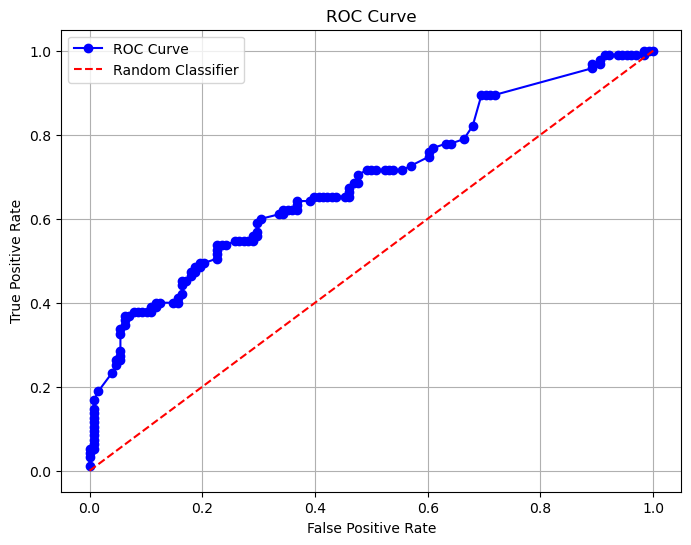

In [20]:
fpr = []
tpr = []



# Calculate FPR and TPR for each threshold
for threshold in thresholds:
    # Convert probabilities to class labels based on the threshold
    preds = (probs >= threshold).astype(int) #------>>> each threshold is applied to the entire probs array (all at once), one threshold at a time.
    
    # Get confusion matrix
    cm = metrics.confusion_matrix(y_test, preds)
    
    # Calculate FPR and TPR
    fp = cm[0][1]  # False Positives
    fn = cm[1][0]  # False Negatives
    tp = cm[1][1]  # True Positives
    tn = cm[0][0]  # True Negatives
    
    fpr.append(fp / (fp + tn))  # False Positive Rate
    tpr.append(tp / (tp + fn))  # True Positive Rate

# Plot FPR vs TPR (ROC Curve)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, marker='o', linestyle='-', color='b', label='ROC Curve')
plt.plot([0, 1], [0, 1], linestyle='--', color='r', label='Random Classifier')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()

### Interactive fpr, tpr, thresholds Plot

In [21]:
#!pip install plotly ---> in case you don't have plotly installed to your environment

In [22]:
#!pip install --upgrade jupyterlab  ------> might be required if plotly complains

In [23]:
#!pip install ipywidgets ------> might be required if plotly complains

In [24]:
# Below plot only works in a browser page for me, hence the following ----> fig.show(renderer='browser')

In [25]:
import plotly.express as px
import pandas as pd

# Create DataFrame
roc_data = pd.DataFrame({
    'FPR': fpr,
    'TPR': tpr,
    'Threshold': thresholds
})

# Plot interactive ROC curve
fig = px.scatter(roc_data, x='FPR', y='TPR', color='Threshold',
                 title='Interactive ROC Curve with Thresholds',
                 labels={'FPR': 'False Positive Rate', 'TPR': 'True Positive Rate'})
fig.show(renderer='browser')

In [26]:
# Uncomment the below for the comparison with the interactive plot
print(f"tpr list:", tpr)
print(f"fpr list:", fpr)
print(f"Thresholds:", thresholds)

tpr list: [1.0, 1.0, 1.0, 0.9894736842105263, 0.9894736842105263, 0.9894736842105263, 0.9894736842105263, 0.9894736842105263, 0.9894736842105263, 0.9894736842105263, 0.9894736842105263, 0.9789473684210527, 0.968421052631579, 0.968421052631579, 0.9578947368421052, 0.8947368421052632, 0.8947368421052632, 0.8947368421052632, 0.8947368421052632, 0.8210526315789474, 0.7894736842105263, 0.7789473684210526, 0.7789473684210526, 0.7684210526315789, 0.7578947368421053, 0.7473684210526316, 0.7263157894736842, 0.7157894736842105, 0.7157894736842105, 0.7157894736842105, 0.7157894736842105, 0.7157894736842105, 0.7157894736842105, 0.7157894736842105, 0.7052631578947368, 0.6842105263157895, 0.6842105263157895, 0.6736842105263158, 0.6631578947368421, 0.6526315789473685, 0.6526315789473685, 0.6526315789473685, 0.6526315789473685, 0.6526315789473685, 0.6526315789473685, 0.6526315789473685, 0.6526315789473685, 0.6421052631578947, 0.6421052631578947, 0.631578947368421, 0.6210526315789474, 0.621052631578947

### Incorporating AUC calculation

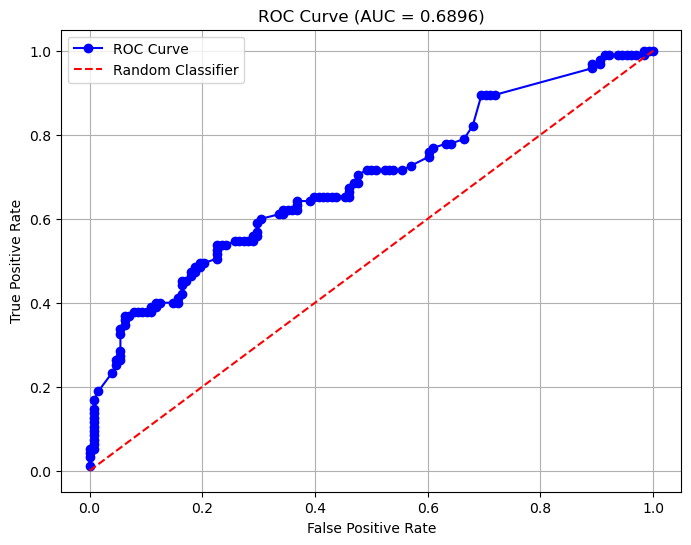

AUC Score: 0.6896


In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Example: Assuming you already have these from previous code
probs = logreg.predict_proba(X_test)[:,1]
thresholds = np.unique(np.sort(probs))  # sorted unique probabilities
fpr = []
tpr = []

# Calculate FPR and TPR for each threshold
for threshold in thresholds:
    # Convert probabilities to class labels based on the threshold
    preds = (probs >= threshold).astype(int)
    
    # Get confusion matrix
    cm = confusion_matrix(y_test, preds)
    
    # Calculate FPR and TPR
    fp = cm[0][1]  # False Positives
    fn = cm[1][0]  # False Negatives
    tp = cm[1][1]  # True Positives
    tn = cm[0][0]  # True Negatives
    
    fpr.append(fp / (fp + tn))  # False Positive Rate
    tpr.append(tp / (tp + fn))  # True Positive Rate

# AUC Calculation using Trapezoidal Rule
fpr = np.array(fpr)
tpr = np.array(tpr)

# Values from fpr and tpr lists should be sorted otherwise, auc might return as a negative variable. We cannot use np.sort on each list either, this would cause the corresponding values to get mixed up. Best way is argsort function

sorted_indices = np.argsort(fpr)      # Get indices that would sort fpr
fpr_sorted = fpr[sorted_indices]      # Sort fpr by those indices
tpr_sorted = tpr[sorted_indices]      # Rearrange tpr to match sorted fpr

# Calculate the area under the curve (AUC) using the trapezoidal rule. The trapezoidal rule is a numerical integration technique used to approximate the area under a curve. When you have multiple data points, the formula helps estimate the area between each pair of consecutive points.

auc = np.trapz(tpr_sorted, fpr_sorted)

# Plot FPR vs TPR (ROC Curve)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, marker='o', linestyle='-', color='b', label='ROC Curve')
plt.plot([0, 1], [0, 1], linestyle='--', color='r', label='Random Classifier')
plt.title(f'ROC Curve (AUC = {auc:.4f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()

# Print AUC score
print(f"AUC Score: {auc:.4f}")


### Calculation of AUC from Scratch

In order to get the AUC score, (if we were not creating the code from scratch) we could have simply used the below sklearn function as follows;

auc_score = roc_auc_score(y_true, y_pred_prob)



However, we are following a manual approach, area under the curve is calculated like in integral, and the rule is as follows;

The trapezoidal rule for numerical integration to calculate the area under the curve is given by:

$$
A = \frac{h}{2} \left( f(x_0) + 2 \sum_{i=1}^{n-1} f(x_i) + f(x_n) \right)
$$

Where:
- $A$ is the approximate area under the curve.
- $h$ is the width of each interval, calculated as: 
  $$
  h = \frac{x_n - x_0}{n}
  $$
  where $x_0$ and $x_n$ are the endpoints of the interval, and $n$ is the number of subintervals.
  
- $f(x_i)$ represents the function values at the points $x_0, x_1, \dots, x_n$.


### Area of Trapezoid (Simple formula):

$$
\text{Area} = \frac{1}{2} (x_2 - x_1) \times (y_1 + y_2)
$$

Where:
- $(x_1)$ and $(x_2)$ are the x-coordinates of the two points.
- $(y_1)$ and $(y_2)$ are the corresponding y-values at those points.



Since we have multiple data points to calculate we apply the above formula in pairs, then add all calculated areas together;
$$
AUC=Area 
1
​
 +Area 
2
​
$$